In [1]:
## Load libraries
import pandas as pd
import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from keras.datasets import mnist
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
plt.style.use('dark_background')
%matplotlib inline

In [2]:
np.set_printoptions(precision=2)

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [4]:
tf.__version__

'2.14.0'

---

Mount Google Drive if running in Colab

---

In [5]:
## Mount Google drive folder if running in Colab
if('google.colab' in sys.modules):
    from google.colab import drive
    drive.mount('/content/drive', force_remount = True)
    DIR = '/content/drive/MyDrive/Colab Notebooks/MAHE/MSIS Coursework/EvenSem2024MAHE'
    DATA_DIR = DIR + '/Data/'
    os.chdir(DIR)
else:
    DATA_DIR = 'Data/'

---

Load diabetes data

---

In [6]:
## Load diabetes data
file = DATA_DIR+'houseprices_cleaned.csv'
df= pd.read_csv(file, header = 0)

print('House price dataset')
print('-----------')
print('Initial number of samples = %d'%(df.shape[0]))
print('Initial number of features = %d\n'%(df.shape[1]))
df.head(5)

House price dataset
-----------
Initial number of samples = 225
Initial number of features = 8



,locality,area,rent,price_per_sqft,facing,BHK,bathrooms,parking
0,BTM Layout,565.0,20060.0,6195.0,North-West,1,1,Bike
1,BTM Layout,1837.0,97434.0,9254.0,East,3,3,Bike and Car
2,BTM Layout,1280.0,54448.0,7422.0,East,2,2,Car
3,BTM Layout,2220.0,117000.0,9234.0,North,3,3,Bike and Car
4,BTM Layout,1113.0,34388.0,5391.0,East,2,2,Bike and Car


In [7]:
## Create lists of ordinal, categorical, and continuous features
#categorical_features =  ['GENDER', 'BMILEVEL']
categorical_features =  ['facing', 'parking', 'locality']
continuous_features = df.drop(categorical_features, axis = 1).columns.tolist()
print(categorical_features)
print(continuous_features)

['facing', 'parking', 'locality']
['area', 'rent', 'price_per_sqft', 'BHK', 'bathrooms']


---

Assign 'category' datatype to categorical columns

---

In [8]:
## Assign 'category' datatype to ordinal and categorical columns
print(df.dtypes)
df[categorical_features] = df[categorical_features].astype('category')
print('----')
df.dtypes

locality           object
area              float64
rent              float64
price_per_sqft    float64
facing             object
BHK                 int64
bathrooms           int64
parking            object
dtype: object
----


locality          category
area               float64
rent               float64
price_per_sqft     float64
facing            category
BHK                  int64
bathrooms            int64
parking           category
dtype: object

---

Remove the target variable column from the list of continuous features

---

In [ ]:
## Remove the target variable column from the list of continuous features
continuous_features.remove('title')

In [13]:
# X = df.drop('price_per_sqft', axis = 1)
X = df
y = df['price_per_sqft']

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

num_features = X_train.shape[1]
num_samples = X_train.shape[0]

print('House price dataset data set')
print('---------------------')
print('Number of training samples = %d'%(num_samples))
print('Number of features = %d'%(num_features))

House price dataset data set
---------------------
Number of training samples = 180
Number of features = 8


---

Build pipeline for categorical and continuous features

---

In [14]:
## Build pipeline for categorical and continuous features

# Pipeline object for categorical (features
categorical_transformer = Pipeline(steps = [('onehotenc', OneHotEncoder(handle_unknown = 'ignore'))])

# Pipeline object for continuous features
continuous_transformer = Pipeline(steps = [('scaler', RobustScaler())])

# Create a preprocessor object for all features
preprocessor = ColumnTransformer(transformers = [('continuous', continuous_transformer, continuous_features),
                                                 ('categorical', categorical_transformer, categorical_features)
                                                ],
                                #  remainder = 'passthrough'
                                 )

---

Fit and transform train data using preprocessor followed by transforming test data

---

In [11]:
print(X_train.head())

         locality    area      rent facing  BHK  bathrooms       parking
85   Marathahalli  1600.0   51583.0   West    3          3  Bike and Car
28       Attibele  1347.0   21091.0  North    3          2  Bike and Car
16     BTM Layout  1025.0   32096.0  North    2          2  Bike and Car
114   Indiranagar  1900.0  103000.0   East    3          2  Bike and Car
122   Indiranagar  1070.0   71643.0  South    2          2           Car


In [ ]:
# # Remove units and convert 'area' feature to numeric
# X_train['area'] = X_train['area'].str.replace(' sqft', '').str.replace(',', '').astype(float)
# X_test['area'] = X_test['area'].str.replace(' sqft', '').str.replace(',', '').astype(float)
    

In [ ]:
# import re

# def convert_rent_to_numeric(rent_str):
#     # Remove commas from the string
#     rent_str = rent_str.replace(',', '')
    
#     # Extract numerical part using regular expression
#     numerical_part = re.findall(r'\d*\.?\d+', rent_str)
    
#     # Check if any numerical part is found
#     if numerical_part:
#         # Convert the numerical part to float
#         rent_value = float(numerical_part[0])
        
#         # Check for units and convert accordingly
#         if 'Lacs' in rent_str:
#             return rent_value * 100000  # Convert Lacs to numeric (1 Lacs = 100,000)
#         elif 'Thousands' in rent_str:
#             return rent_value * 1000  # Convert Thousands to numeric (1 Thousand = 1,000)
#         else:
#             return rent_value
#     else:
#         return None  # Return None for invalid values

# # Apply custom function to preprocess 'rent' column
# X_train['rent'] = X_train['rent'].apply(convert_rent_to_numeric)
# X_test['rent'] = X_test['rent'].apply(convert_rent_to_numeric)


In [ ]:
# def convert_price_per_sqft_to_numeric(price_per_sqft_str):
#     # Remove unwanted characters from the string
#     price_per_sqft_str = price_per_sqft_str.replace('₹', '').replace(',', '').replace(' per sq.ft.', '')
    
#     # Extract numerical part using regular expression
#     numerical_part = re.findall(r'\d*\.?\d+', price_per_sqft_str)
    
#     # Check if any numerical part is found
#     if numerical_part:
#         # Convert the numerical part to float
#         return float(numerical_part[0])
#     else:
#         return None  # Return None for invalid values

# # Apply custom function to preprocess 'price_per_sqft' column
# X_train['price_per_sqft'] = X_train['price_per_sqft'].apply(convert_price_per_sqft_to_numeric)
# X_test['price_per_sqft'] = X_test['price_per_sqft'].apply(convert_price_per_sqft_to_numeric)


In [15]:
## Fit and transform train data using preprocessor
X_train_transformed = preprocessor.fit_transform(X_train).T
# Update number of features
num_features = X_train_transformed.shape[0]
# Transform training data using preprocessor
X_test_transformed = preprocessor.transform(X_test).T
# Convert Y_train and Y_test to numpy arrays
Y_train = Y_train.to_numpy()
Y_test = Y_test.to_numpy()


---

A generic layer class with forward and backward methods

----

In [16]:
class Layer:
  def __init__(self):
    self.input = None
    self.output = None

  def forward(self, input):
    pass

  def backward(self, output_gradient, learning_rate):
    pass

---

Mean squared error (MSE) loss and its gradient

---

In [17]:
## Define the loss function and its gradient
def mse(Y, Yhat):
  return(np.mean(0.5*(Y - Yhat)**2))
  #TensorFlow in-built function for mean squared error loss
  #mse = tf.keras.losses.MeanSquaredError()
  #mse(Y, Yhat).numpy()

def mse_gradient(Y, Yhat):
  return(Yhat - Y)

---

Generic activation layer class

---

In [18]:
class Activation(Layer):
    def __init__(self, activation, activation_gradient):
        self.activation = activation
        self.activation_gradient = activation_gradient

    def forward(self, input):
        self.input = input
        self.output = self.activation(self.input)
        return(self.output)

    def backward(self, output_gradient, learning_rate = None):
        return(output_gradient[:-1, :] * self.activation_gradient(self.input))

---

Specific activation layer classes

---

In [19]:
class Sigmoid(Activation):
    def __init__(self):
        def sigmoid(z):
            return 1 / (1 + np.exp(-z))

        def sigmoid_gradient(z):
            a = sigmoid(z)
            return a * (1 - a)

        super().__init__(sigmoid, sigmoid_gradient)

class Tanh(Activation):
    def __init__(self):
        def tanh(z):
            return np.tanh(z)

        def tanh_gradient(z):
            a = np.tanh(z)
            return 1 - a**2

        super().__init__(tanh, tanh_gradient)

class ReLU(Activation):
    def __init__(self):
        def relu(z):
            return z * (z > 0)

        def relu_gradient(z):
            return 1. * (z > 0)

        super().__init__(relu, relu_gradient)

---

Dense layer class

---

In [20]:
## Dense layer class
class Dense(Layer):
    def __init__(self, input_size, output_size, reg_strength):
        self.weights = 0.01*np.random.randn(output_size, input_size+1) # bias trick
        self.weights[:, -1] = 0.01 # set all bias values to the same nonzero constant
        self.reg_strength = reg_strength
        self.reg_loss = None

    def forward(self, input):
        self.input = np.vstack([input, np.ones((1, input.shape[1]))]) # bias trick
        self.output= np.dot(self.weights, self.input)
        # Calculate regularization loss
        self.reg_loss = self.reg_strength * np.sum(self.weights[:, :-1] * self.weights[:, :-1])

    def backward(self, output_gradient, learning_rate):
        ## Following is the inefficient way of calculating the backward gradient
        #weights_gradient = np.zeros((self.output.shape[0], self.input.shape[0]), dtype = np.float64)
        #for b in range(output_gradient.shape[1]):
        #  weights_gradient += np.dot(output_gradient[:, b].reshape(-1, 1), self.input[:, b].reshape(-1, 1).T)
        #weights_gradient = (1/output_gradient.shape[1])*weights_gradient

        ## Following is the efficient way of calculating the weights gradient w.r.t. data
        weights_gradient = (1/output_gradient.shape[1])*np.dot(np.atleast_2d(output_gradient), np.atleast_2d(self.input).T)
        # Add the regularization gradient here
        weights_gradient += 2 * self.reg_strength * np.hstack([self.weights[:, :-1], np.zeros((self.weights.shape[0], 1))])


        input_gradient = np.dot(self.weights.T, output_gradient)
        self.weights = self.weights + learning_rate * (-weights_gradient)

        return(input_gradient)

---

Function to generate sample indices for batch processing according to batch size

---

In [21]:
## Function to generate sample indices for batch processing according to batch size
def generate_batch_indices(num_samples, batch_size):
  # Reorder sample indices
  reordered_sample_indices = np.random.choice(num_samples, num_samples, replace = False)
  # Generate batch indices for batch processing
  batch_indices = np.split(reordered_sample_indices, np.arange(batch_size, len(reordered_sample_indices), batch_size))
  return(batch_indices)

---

Train the 3-layer neural network (8/8/1 structure) using batch training with batch size = 16

---

In [22]:
## Train the 2-hidden layer neural network (8 nodes, 8 nodes followed by 1 node)
## using batch training with batch size = 100
learning_rate = 1e-04 # learning rate
batch_size = 32 # batch size
nepochs = 10000 # number of epochs
reg_strength = 1.0 # regularization strength
# Create empty array to store training losses over each epoch
loss_train_epoch = np.empty(nepochs, dtype = np.float64)
# Create empty array to store test losses over each epoch
loss_test_epoch = np.empty(nepochs, dtype = np.float64)


# Neural network architecture

dlayer1 = Dense(num_features, 16, reg_strength) # define dense layer 1
alayer1 = Tanh() # ReLU activation layer 1
dlayer2 = Dense(16, 1, reg_strength) # define dense layer 2


# Steps: run over each sample in the batch, calculate loss, gradient of loss,
# and update weights.

epoch = 0
while epoch < nepochs:
  batch_indices = generate_batch_indices(num_samples, batch_size)
  loss = 0
  for b in range(len(batch_indices)):
    # Forward propagation for training data
    dlayer1.forward(X_train_transformed[:, batch_indices[b]]) # forward prop dense layer 1 with batch feature added
    alayer1.forward(dlayer1.output) # forward prop activation layer 1
    dlayer2.forward(alayer1.output) # forward prop dense layer 2
    # Calculate training data loss
    loss += mse(Y_train[batch_indices[b]], dlayer2.output)
    # Add the regularization losses
    loss += dlayer1.reg_loss + dlayer2.reg_loss

    # Backward prop starts here
    grad = mse_gradient(Y_train[batch_indices[b]], dlayer2.output)
    grad = dlayer2.backward(grad, learning_rate)
    grad = alayer1.backward(grad)
    grad = dlayer1.backward(grad, learning_rate)
  # Calculate the average training loss for the current epoch
  loss_train_epoch[epoch] = loss/len(batch_indices)

  # Forward propagation for test data
  dlayer1.forward(X_test_transformed)
  alayer1.forward(dlayer1.output)
  dlayer2.forward(alayer1.output)

  # Calculate test data loss plus regularization loss
  loss_test_epoch[epoch] =  mse(Y_test, dlayer2.output) + dlayer1.reg_loss + dlayer2.reg_loss

  print('Epoch %d: train loss = %f, test loss = %f'%(epoch+1, loss_train_epoch[epoch], loss_test_epoch[epoch]))
  epoch = epoch + 1

Epoch 1: train loss = 29679035.775266, test loss = 24947058.214224
Epoch 2: train loss = 28893243.288386, test loss = 24513505.492932
Epoch 3: train loss = 28901295.069693, test loss = 24061604.937966
Epoch 4: train loss = 27884081.837297, test loss = 23623505.002653
Epoch 5: train loss = 27824070.507953, test loss = 23191431.108887
Epoch 6: train loss = 27331242.409509, test loss = 22770528.483241
Epoch 7: train loss = 27316139.055788, test loss = 22356962.984013
Epoch 8: train loss = 26771933.682363, test loss = 21953453.039252
Epoch 9: train loss = 25992615.668297, test loss = 21561713.634045
Epoch 10: train loss = 26392183.343109, test loss = 21173289.133804
Epoch 11: train loss = 25237859.551000, test loss = 20798055.320253
Epoch 12: train loss = 25633152.755985, test loss = 20427050.104718
Epoch 13: train loss = 24600352.576232, test loss = 20069254.078831
Epoch 14: train loss = 24292801.452533, test loss = 19718434.314674
Epoch 15: train loss = 23582535.548847, test loss = 19378

---

Plot training loss vs. epoch

---

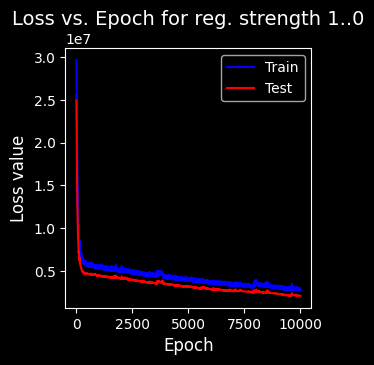

In [23]:
# Plot train and test loss as a function of epoch:
fig, ax = plt.subplots(1, 1, figsize = (4, 4))
fig.tight_layout(pad = 4.0)
ax.plot(loss_train_epoch, 'b', label = 'Train')
ax.plot(loss_test_epoch, 'r', label = 'Test')
ax.set_xlabel('Epoch', fontsize = 12)
ax.set_ylabel('Loss value', fontsize = 12)
ax.legend()
ax.set_title('Loss vs. Epoch for reg. strength 1..0', fontsize = 14);

---

Test performance on test data

---

In [24]:
dlayer1.forward(X_test_transformed)
alayer1.forward(dlayer1.output)
dlayer2.forward(alayer1.output)
ypred = dlayer2.output.flatten()
ytrue = Y_test

---

Define neural network architecture for regression

---

In [31]:
# Define neural network architecture for regression
model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(X_train_transformed.T.shape[1], )),
    layers.Dropout(0.2),  # Dropout regularization
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),  # Dropout regularization
    layers.Dense(8, activation='relu'),
    layers.Dense(1)
])


---

Compile the neural network

---

In [35]:
# Compile the neural network model
opt = tf.keras.optimizers.Adam(learning_rate = 5e-04)
model.compile(optimizer = opt, loss = 'mean_squared_error')

---

Train the model

---

In [36]:
# Train the model
history = model.fit(X_train_transformed.T, Y_train, epochs = 10000, batch_size = 32, validation_data=(X_test_transformed.T, Y_test))

Epoch 1/10000


6/6 [==============================] - 1s 31ms/step - loss: 1449575.8750 - val_loss: 74497.1641
Epoch 2/10000
6/6 [==============================] - 0s 6ms/step - loss: 1539159.8750 - val_loss: 80280.5703
Epoch 3/10000
6/6 [==============================] - 0s 7ms/step - loss: 1566399.6250 - val_loss: 78539.7188
Epoch 4/10000
6/6 [==============================] - 0s 7ms/step - loss: 1285339.8750 - val_loss: 77653.4688
Epoch 5/10000
6/6 [==============================] - 0s 9ms/step - loss: 1492574.3750 - val_loss: 81629.3359
Epoch 6/10000
6/6 [==============================] - 0s 7ms/step - loss: 1285033.6250 - val_loss: 84844.2812
Epoch 7/10000
6/6 [==============================] - 0s 7ms/step - loss: 1355411.2500 - val_loss: 88019.2656
Epoch 8/10000
6/6 [==============================] - 0s 7ms/step - loss: 1867375.2500 - val_loss: 99988.7109
Epoch 9/10000
6/6 [==============================] - 0s 7ms/step - loss: 1425453.7500 - val_loss: 105513.5312
Epoch 10/10000
6/6 [===========

---

Plot train and test loss as a function of epoch

---

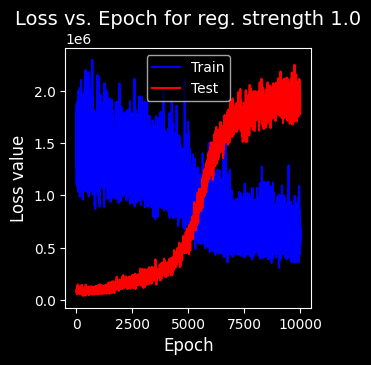

In [37]:
# Plot train and test loss as a function of epoch:
fig, ax = plt.subplots(1, 1, figsize = (4, 4))
fig.tight_layout(pad = 4.0)
ax.plot( history.history['loss'], 'b', label = 'Train')
ax.plot( history.history['val_loss'], 'r', label = 'Test')
ax.set_xlabel('Epoch', fontsize = 12)
ax.set_ylabel('Loss value', fontsize = 12)
ax.legend()
ax.set_title('Loss vs. Epoch for reg. strength 1.0', fontsize = 14);

---

Compare the true and predicted values

---

In [29]:
## Compare the true and predicted values
ypred_TF = model.predict(X_test_transformed.T)
np.column_stack((Y_test, ypred, ypred_TF))

2/2 [==============================] - 1s 3ms/step


array([[5.46e+03, 5.37e+03, 1.37e+03],
       [9.40e+03, 9.24e+03, 2.43e+03],
       [4.71e+03, 4.28e+03, 1.31e+03],
       [5.80e+03, 5.71e+03, 1.51e+03],
       [9.67e+03, 9.24e+03, 2.62e+03],
       [8.90e+03, 7.97e+03, 4.56e+03],
       [3.40e+03, 3.62e+03, 1.01e+03],
       [1.30e+04, 9.24e+03, 3.32e+03],
       [4.00e+03, 4.23e+03, 5.94e+00],
       [5.00e+03, 4.14e+03, 1.04e+03],
       [5.39e+03, 5.99e+03, 1.48e+03],
       [7.96e+03, 8.56e+03, 2.47e+03],
       [1.00e+04, 9.24e+03, 2.07e+03],
       [4.80e+03, 4.71e+03, 1.40e+03],
       [3.85e+03, 3.61e+03, 1.10e+03],
       [8.85e+03, 9.22e+03, 2.76e+03],
       [3.46e+03, 3.61e+03, 1.06e+03],
       [8.99e+03, 9.24e+03, 3.63e+03],
       [5.88e+03, 5.72e+03, 2.20e+03],
       [1.37e+04, 9.24e+03, 4.97e+03],
       [8.33e+03, 8.56e+03, 1.91e+03],
       [3.85e+03, 3.61e+03, 1.24e+03],
       [4.00e+03, 4.23e+03, 2.07e+02],
       [6.58e+03, 6.65e+03, 4.09e+03],
       [2.93e+03, 4.23e+03, 3.95e+02],
       [6.00e+03, 4.91e+0